In [94]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import itertools as it
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
#Testing over a set of tech companies, search can easily be extended by adding more companies.
Companies=['NVDA','AAPL','MSFT','AVGO','AMD','GOOG','AMZN','META']
#Stock prices of companies over a 5 year period at close.
RealisationMatrix=yf.download(Companies,period='5y')['Close']

[*********************100%***********************]  8 of 8 completed


In [95]:
RealisationMatrix.head()

Ticker,AAPL,AMD,AMZN,AVGO,GOOG,META,MSFT,NVDA
Date,,,,,,,,
2021-07-26,145.228287,91.820000,184.990997,43.902306,138.424057,369.217743,277.400299,19.227495
2021-07-27,143.064346,91.029999,181.319504,43.275951,135.600937,364.608124,274.991486,19.141790
2021-07-28,141.319550,97.930000,181.516006,43.484432,135.189560,370.030579,274.684448,19.435772
2021-07-29,141.962875,102.949997,179.996002,44.072540,135.347183,355.200745,274.953125,19.594231
2021-07-30,142.177277,106.190002,166.379501,44.189987,134.039185,353.198334,273.427216,19.431789


In [3]:
#Dropping incomplete entires, and taking log for scale-invariance
CleanMatrix_original=RealisationMatrix.dropna()
CleanMatrix=np.log(CleanMatrix_original)

In [107]:
#Calculates number of days for the divergence of a pair of stocks from their mean relationship to half
#Achieved via Ornstein-Uhlenbeck process
def calculate_half_life(spread):
    ds=spread.diff().dropna() #change in spread (Delta S_t)
    lag=spread.shift(1).dropna() #lagged spread (S_{t-1})
   
    #Fit OLS regression: Delta S_t = alpha + gamma * S_{t-1} + e_t
    model = sm.OLS(ds,sm.add_constant(lag)).fit()
    gamma = model.params.iloc[1]    

    #returns half life, valid iff gamma < 0 
    return -np.log(2)/gamma if gamma<0 else np.inf

In [32]:
#Find cointegrated pairs with p-value under threshold
def pair(prices,p_threshold=0.05):
    results=[]
    
    #Iterating for each unique pair of stocks
    for A,B in it.combinations(prices.columns,2):
        y=prices[A]
        x=prices[B]
        
        #Engle-Granger test, low p proves long term equilibrium
        p_value=coint(y,x)[1]
        if p_value<p_threshold:
            
            #Computing half life and Beta (hedge ratio) of model A=alpha+beta*B (Static Cointegrating Regression)
            beta = sm.OLS(y, sm.add_constant(x)).fit().params.iloc[1]
            spread = y - (beta * x)
            hl = calculate_half_life(spread)            
            results.append({'Pair': f"{A} - {B}",'p_value': round(p_value, 4),'beta': round(beta, 4),'half_life_days': round(hl, 1)})
    return pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)        

In [33]:
pair(CleanMatrix)

,Pair,p_value,beta,half_life_days
0,META - MSFT,0.0309,2.2007,39.9
1,AAPL - AVGO,0.0345,0.2862,36.6
2,META - NVDA,0.0452,0.5562,57.5


In [34]:
#Apply kalman filter to a pair of stocks to create a series of Beta's (Hedge Ratios) and the corresponding spread/spread std
#x,y = stock 1,stock 2, delta = Process variance (dictates how fast Beta can change), 
#R = Measurement Noise Variance (Represents level of background noise), warmup=number of days to train our intial Beta over
def kalman_filter(x,y,delta=1e-4,R=1,warmup=30,z_window=30):
    n=len(x)
    betas=np.zeros(n)
    spreads=np.zeros(n)
    
    #Calculating an intial Beta over warmup period with OLS as in def pair()
    warmup_x = sm.add_constant(x.iloc[:warmup])
    warmup_y = y.iloc[:warmup]
    ols = sm.OLS(warmup_y, warmup_x).fit()
    beta_prev = ols.params.iloc[1]
    betas[:warmup]=beta_prev
   
    P_prev=ols.bse.iloc[1]**2 #Estimate variance of error of Beta
    Q=delta/(1-delta) #Process noise covariance

    for t in range(warmup,n):
        xt=x.iloc[t]
        yt=y.iloc[t]

        et=yt-beta_prev*xt #Spread estimate
        St=((xt**2)*P_prev)+R #Measurement variance
        Kt=(xt*P_prev)/St #Kalman gain
        beta_new=beta_prev+(Kt*et) #Updating Beta value
        P_new=P_prev*(1-Kt*xt)+Q #Updating variance of error

        betas[t]=beta_new
        spreads[t]=et
        beta_prev=beta_new
        P_prev=P_new

    beta_series = pd.Series(betas[warmup:],index=y.index[warmup:],name="Beta")
    spread_series = pd.Series(spreads[warmup:],index=y.index[warmup:],name="Spread")
    rolling_mean = spread_series.rolling(window=z_window).mean()
    rolling_std = spread_series.rolling(window=z_window).std()
    z_score_series = (spread_series - rolling_mean) / rolling_std
    valid_idx = z_score_series.dropna().index        
    return beta_series.loc[valid_idx],spread_series.loc[valid_idx],z_score_series.loc[valid_idx]

In [35]:
stockx=CleanMatrix['MSFT']
stocky=CleanMatrix['META']
beta_MM,spread_MM,z_MM=kalman_filter(stockx,stocky,delta=1e-2,z_window=15)
summary=pd.DataFrame({'Beta':beta_MM, 'Spread':spread_MM,'Z-Score':z_MM})
summary.tail(5).style.format({'Beta':'{:.4f}','Spread':'${:.2f}','Z-Score':'{:.2f}'})

,Beta,Spread,Z-Score
Date,,,
2026-07-17 00:00:00,1.0852,$-0.03,-1.06
2026-07-20 00:00:00,1.0824,$-0.04,-1.40
2026-07-21 00:00:00,1.0815,$-0.01,-0.61
2026-07-22 00:00:00,1.0806,$-0.01,-0.61
2026-07-23 00:00:00,1.0794,$-0.02,-0.62


In [36]:
#Generating trading position based on Z_scores from Kalman Filter
#0=exit/close position, 1 = (buy y, short x), -1 = (short y, buy x)
def signals(Z_scores,entry=1,exit=0.25):
    n=len(Z_scores)
    positions=np.zeros(n)
    current_position=0
    for i in range(n):
        z=Z_scores.iloc[i]
        if current_position == 1:
            if z >= -exit:
                current_position = 0
        elif current_position == -1:
            if z <= exit:
                current_position = 0    
        if current_position == 0:
            if z >= entry:
                current_position = -1  # Short Y, Buy X
            elif z <= -entry:
                current_position = 1   # Buy Y, Short X
        positions[i] = current_position        
    return  pd.Series(positions,index=Z_scores.index,name="Position")

In [87]:
#Calculating returns
def returns(x,y,positions,betas,capital=10000):
    idx=positions.index
    xreturn=x.loc[idx].diff()
    yreturn=y.loc[idx].diff()
    beta_aligned=betas.loc[idx]
    traded_beta=beta_aligned.shift(1).fillna(beta_aligned.iloc[0])
    spread_return=(yreturn-traded_beta*xreturn)/(1+traded_beta)
    traded_pos=positions.shift(1).fillna(0)
    strat_returns=traded_pos*spread_return
    portfolio_value=capital*(1+strat_returns).cumprod()
    return pd.DataFrame({'Position': positions,'Traded_Position': traded_pos,'Spread_Return': spread_return,
        'Strategy_Return': strat_returns,'Portfolio_Value': portfolio_value}, index=xreturn.index) 
    
#Calculating returns with both leverage and cash yeild when no position open
def returns_enhanced(x, y, positions, betas, capital=10000, leverage=2.0, rf_annual=0.045):
    idx = positions.index
    xreturn = x.loc[idx].diff()
    yreturn = y.loc[idx].diff()
    traded_pos = positions.shift(1).fillna(0)
    traded_beta = betas.loc[idx].shift(1).fillna(betas.iloc[0])
    spread_return = (yreturn - traded_beta * xreturn)/(1+traded_beta)
    daily_rf = rf_annual / 252
    cash_mask = traded_pos == 0
    active_returns = traded_pos * spread_return * leverage
    cash_returns = cash_mask * daily_rf

    combined_returns = active_returns + cash_returns
    portfolio_value = capital * (1 + combined_returns).cumprod()

    return pd.DataFrame({"Position": positions,"Traded_Position": traded_pos,"Combined_Return": combined_returns,
                         "Portfolio_Value": portfolio_value,},index=idx,)


In [88]:
pos_MM=signals(z_MM,entry=1,exit=0.25)
growth_MM=returns(stockx,stocky,pos_MM,beta_MM)
print(growth_MM['Position'].value_counts())
growth.tail(10)

Position
 0.0    630
-1.0    298
 1.0    282
Name: count, dtype: int64


,Position,Traded_Position,Spread_Return,Strategy_Return,Portfolio_Value
Date,,,,,
2026-07-10,-1.0,-1.0,0.026917,-0.026917,14163.789352
2026-07-13,0.0,-1.0,-0.016928,0.016928,14403.547978
2026-07-14,0.0,0.0,0.011268,0.000000,14403.547978
2026-07-15,0.0,0.0,0.000177,0.000000,14403.547978
2026-07-16,1.0,0.0,-0.019088,-0.000000,14403.547978
2026-07-17,1.0,1.0,-0.004010,-0.004010,14345.791662
2026-07-20,1.0,1.0,-0.011193,-0.011193,14185.219350
2026-07-21,1.0,1.0,0.004380,0.004380,14247.351040
2026-07-22,1.0,1.0,-0.002809,-0.002809,14207.325749


In [89]:
#Computing metrics in order to test parameter values
def metrics(growth):
    strat_returns=growth['Strategy_Return']
    portfolio_value=growth['Portfolio_Value']
    traded_pos=growth['Traded_Position']

    #Annualizied Sharpe Ratio: Quantifies whether returns are worth the risk
    R_mean=strat_returns.mean()
    R_std=strat_returns.std()
    SR=((R_mean/R_std*np.sqrt(252)) if R_std > 0 else 0)

    #Maximun Drawdown: Largest drop in portfolio value
    Pmax=portfolio_value.cummax()
    drawdown=(portfolio_value-Pmax)/Pmax
    max_drawdown=drawdown.min()*100

    #Trade Execution: Number of profitable days vs Number of trading days
    active=strat_returns[traded_pos != 0]
    total=len(active)
    if total > 0:
        win=(active>0).sum()
        winrate=win/total*100 #winrate as percentage
    elif total == 0:
        winrate=0
    trades=((traded_pos!=0)&(traded_pos.shift(1).fillna(0)==0)).sum()

    return {"Sharpe_Ratio": round(SR, 2),"Max_Drawdown_%": round(max_drawdown, 2),"Win_Rate_%": round(winrate, 2),
        "Total_Trades": trades,"Ending_Value_$ef": round(portfolio_value.iloc[-1], 2),}

In [90]:
pd.Series(metrics(growth_MM), name="Value")

Sharpe_Ratio            0.57
Max_Drawdown_%        -25.05
Win_Rate_%             51.81
Total_Trades          161.00
Ending_Value_$ef    14141.46
Name: Value, dtype: float64

In [91]:
#Computing metrics for range of parameter values
def parasearch(x,y):
    z_windows=[15,30,45]
    exit_values=[0,0.25,0.5]
    entry_values=[1,1.5,2]
    results=[]
    for zwin in z_windows:
        b_series,s_series,z_series=kalman_filter(x,y,z_window=zwin)
        for entry in entry_values:
            for exit in exit_values:
                signal_series=signals(z_series,entry=entry,exit=exit)
                growth_vals=returns(x,y,signal_series,b_series)
                metric_vals=metrics(growth_vals)
                metric_vals.update({'z_window': zwin, 'entry': entry, 'exit': exit})
                results.append(metric_vals)               
    results_df=pd.DataFrame(results)
    return results_df

In [92]:
grid_results = parasearch(stockx, stocky)
valid_runs = grid_results[grid_results["Total_Trades"] >= 15].sort_values(by="Sharpe_Ratio", ascending=False)
print("=== TOP 5 PARAMETER SETS BY SHARPE RATIO ===")
print(valid_runs.head(5).to_string(index=False))
#The following table gives us an idea of the optimal choice of parameters.
#We could improve code by futher iterating over detla values to find an optimal choice of such, or iterating over more
#values for each parameter in parasearch().
#We could also improve code by assigning a weight to each value, notating its performance for each set of parameters
#giving us a less opinion based set of optimal values.

=== TOP 5 PARAMETER SETS BY SHARPE RATIO ===
 Sharpe_Ratio  Max_Drawdown_%  Win_Rate_%  Total_Trades  Ending_Value_$ef  z_window  entry  exit
         0.91           -9.56       52.09            44          14676.25        30    2.0  0.50
         0.82          -11.32       52.73            66          15019.53        30    1.5  0.50
         0.81          -16.86       52.55            43          14763.19        30    2.0  0.25
         0.70          -14.11       54.09            49          13932.41        45    1.5  0.50
         0.66           -9.24       51.86            29          12716.89        45    2.0  0.50


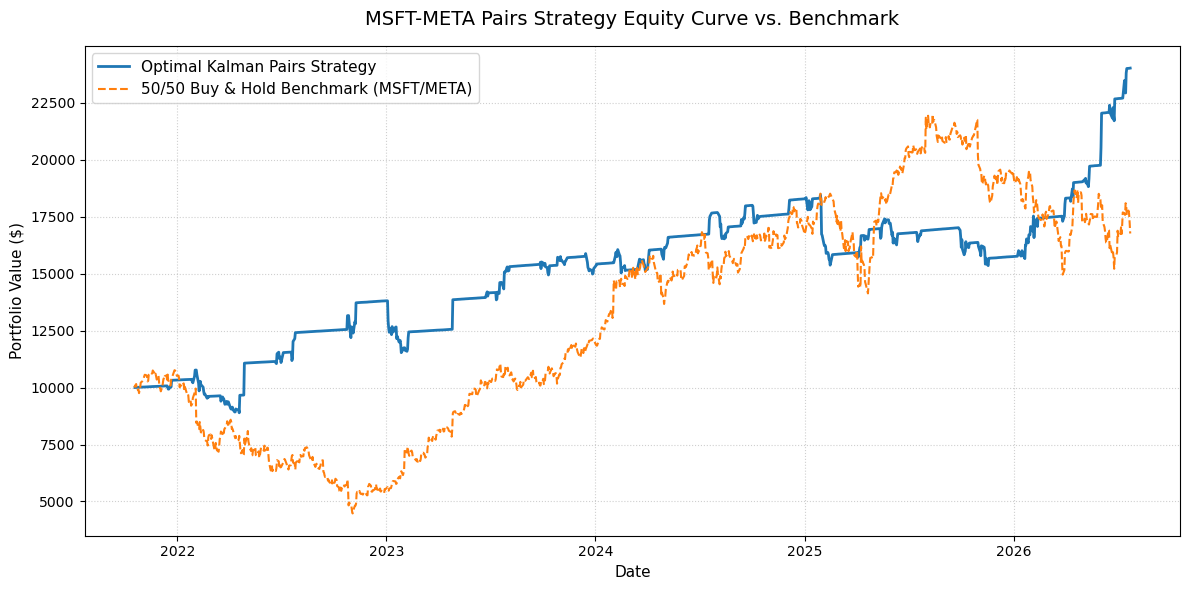

In [105]:
best_z_win = 30
best_entry = 2.0
best_exit = 0.50

b_series, s_series, z_series = kalman_filter(stockx, stocky, delta=1e-4, z_window=best_z_win)
optimal_signals = signals(z_series, entry=best_entry, exit=best_exit)
optimal_growth = returns_enhanced(stockx, stocky, optimal_signals, b_series, capital=10000)

price_x = np.exp(stockx.loc[optimal_growth.index])
price_y = np.exp(stocky.loc[optimal_growth.index])
ret_x = price_x.pct_change().fillna(0)
ret_y = price_y.pct_change().fillna(0)
benchmark_returns = 0.5 * ret_x + 0.5 * ret_y
benchmark_equity = 10000 * (1 + benchmark_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(optimal_growth.index,optimal_growth["Portfolio_Value"],label="Optimal Kalman Pairs Strategy",linewidth=2,)
plt.plot(optimal_growth.index,benchmark_equity,label="50/50 Buy & Hold Benchmark (MSFT/META)",linestyle="--",linewidth=1.5)
plt.title("MSFT-META Pairs Strategy Equity Curve vs. Benchmark", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Portfolio Value ($)", fontsize=11)
plt.legend(fontsize=11, loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#Code is heavily biased on training data, futher backtesting is required to highlight whether model works.
#The next step would be to trade multiple sets of pairs, to avoid stationary and high risk periods of trading.
#Transaction costs need to also be included, affecting gains when a significant amount of trades are performed.